In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from random import randrange
import warnings
from scipy import linalg    
import seaborn as sns
from scipy.stats import linregress
from scipy.spatial import Delaunay
from collections import defaultdict
warnings.filterwarnings('ignore')

datadir = "//Users/billiemeadowcroft/Dropbox/PostDocCode/IlyaMethod/WorkingSetup/DataCSVs/"
datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/IlyaMethod/ExtractingNoise/DataCSVs/"
datadir0 = "/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/InferenceScripts/UD_run/"
plotsdir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Plots/"
cmap = plt.cm.get_cmap('BuPu')
clrs=["#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84","#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84"]
clrs2=["#b59837","#fc8d59","#d7301f","#6f0606","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695","#fef0d9","#fdcc8a","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695"]
clrs3=["#313695","#623CA2","#B546CE"]

Some simulation definitions:

In [2]:
def parse_lammps_xyz(filename):
    data = []
    with open(filename, 'r') as file:
        while True:
            line = file.readline()
            if not line:
                break  # EOF
            
            if "ITEM: TIMESTEP" in line:
                timestep = int(file.readline().strip())
                file.readline()  # Skip "ITEM: NUMBER OF ATOMS"
                num_atoms = int(file.readline().strip())
                file.readline()  # Skip "ITEM: BOX BOUNDS ..."
                file.readline()
                file.readline()
                file.readline()
                file.readline()  # Skip "ITEM: ATOMS id type x y z"
                
                for _ in range(num_atoms):
                    atom_line = file.readline()
                    if not atom_line:
                        break  # Unexpected EOF
                    parts = atom_line.strip().split()
                    atom_id, atom_type = int(parts[0]), int(parts[1])
                    x, y, z = map(float, parts[2:5])
                    data.append({
                        "timestep": timestep,
                        "id": atom_id,
                        "type": atom_type,
                        "x": x,
                        "y": y,
                        "z": z
                    })

    df = pd.DataFrame(data)
    return df

# Unwrapping the trajectories
# The function unwrap_trajectories takes a DataFrame with atom trajectories and unwraps them based on periodic boundary conditions.

def unwrap_trajectories(df, box_length_x, box_length_y):
    # Sort the DataFrame by atom ID and timestep
    df = df.sort_values(by=["id", "timestep"]).copy()
    unwrapped_rows = []

    for atom_id, group in df.groupby("id"):
        group = group.sort_values(by="timestep").copy()
        x = group["x"].values
        y = group["y"].values
        timesteps = group["timestep"].values
        unwrappedX = np.zeros_like(x)
        unwrappedY = np.zeros_like(y)
        #unwrappedX = [x[0]]
        #unwrappedY = [y[0]]
        unwrappedX[0] = x[0]
        unwrappedY[0] = y[0]
        
        shiftX = 0.0
        shiftY = 0.0

        for i in range(1, len(x)):
            dx = x[i] - x[i - 1]
            dy = y[i] - y[i - 1]
            if dx > box_length_x / 2:
                #print('dx > box_length_x / 2')
                shiftX -= box_length_x
            if dy > box_length_y / 2:
                #print('dy > box_length_y / 2')
                shiftY -= box_length_y
            if dx < -box_length_x / 2:
                #print('dx < -box_length_x / 2')
                shiftX += box_length_x
            if dy < -box_length_y / 2:
                #print('dy < -box_length_y / 2')
                shiftY += box_length_y
            #print('i',i)
            #print('len(UnwrappedX)',len(unwrappedX))
            unwrappedX[i] = x[i] + shiftX
            unwrappedY[i] = y[i] + shiftY
            # if shiftX != 0 or shiftY != 0:
            #     print(f"Atom {atom_id} at timestep {timesteps[i]} shifted by ({shiftX}, {shiftY})")
            #     print("box_size_x", box_length_x)

        group["x_unwrapped"] = unwrappedX
        group["y_unwrapped"] = unwrappedY
        unwrapped_rows.append(group)

    return pd.concat(unwrapped_rows, ignore_index=True) #df

# Function to write positions to .xyz file
def write_xyz(f, positions, step,box_length):
    #with open(f, 'a') as f:
    f.write("ITEM: TIMESTEP\n")
    f.write(f"{step}\n")
    f.write("ITEM: NUMBER OF ATOMS\n")
    f.write(f"{len(positions)}\n")
    # Write box dimensions (optional)
    f.write("ITEM: BOX BOUNDS pp pp pp\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"0.0 0.1\n")
    f.write("ITEM: ATOMS id type x y z\n")
    i=0
    for pos in positions:
        i+=1
        f.write(f"{i} 1 {pos[0]} {pos[1]} 0.0\n") 
        #f.write(f"1 {pos[0]} {pos[1]} 0.0\n")  # Assuming particles are Argon atoms



Specific initial conditions:

In [3]:
def InitialPositions(num_particles, box_size, sigma, cluster_size):
    """Generate clustered initial positions in a 2D box, avoiding overlaps."""
    positions = []
    placed_particles = 0
    cluster_centers = []

    num_clusters = max(1, num_particles // cluster_size)

    for _ in range(num_clusters):
        center = np.random.uniform(-box_size / 2 + 3*sigma, box_size / 2 - 3*sigma, size=2)
        cluster_centers.append(center)

    for center in cluster_centers:
        # Calculate how many rows/cols we need
        particles_to_place = min(cluster_size, num_particles - placed_particles)
        grid_dim = int(np.ceil(np.sqrt(particles_to_place)))
        spacing = sigma * 1.1  # Slight buffer to avoid touching

        # Create a grid centered on (0,0), then shift to cluster center
        for i in range(grid_dim):
            for j in range(grid_dim):
                if placed_particles >= num_particles or (i * grid_dim + j) >= particles_to_place:
                    break
                offset = np.array([(i - grid_dim // 2) * spacing,
                                   (j - grid_dim // 2) * spacing])
                candidate = center + offset

                # Stay inside the box
                if (-box_size/2 + sigma < candidate[0] < box_size/2 - sigma and
                    -box_size/2 + sigma < candidate[1] < box_size/2 - sigma):
                    positions.append(candidate)
                    placed_particles += 1

    return np.array(positions)



In [4]:
# # original parameters:
# damp = 10.0  # Friction coefficient
# num_steps = 100000 #Number of simulation steps
# equilibration_steps = 5000 #Steps to equilibrate, these are the number of steps with attraction 
# name = "outputSig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_eps"+str(epsilon)+"cluster_size"+str(cluster_size)+".xyz"




Simulation itself:

In [61]:
# write a lammps config file and input file
## Standard Parameters
for pp in range(1):
    epsilon1 = 0.0 #0.0 #0.5 #0.5
    epsilon2 = 0.0
    #epsilon2 = 3.0 #0.0 #0.5 #0.5
    sigma = 1.5 #1.25 #2.5 #+ee*0.5
    rcut1=sigma*3 #1.22 # repulsion only
    rcut2 = sigma*2 # some attraction
    l_da1 = 0.3 # Softening parameter for the Lennard-Jones potential
    l_da2 = 0.1 # Softening parameter for the Lennard-Jones potential
    #rcut1 = rcut2
    cluster_size= 10 
    num_particles = 20
    kappa = 0.1 # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    #num_particles = 17 #100
    box_size = 30.0  # Box is a cube of size box_size x box_size
    temperature = 0.01 #1.0 #1.0 #0.2 #0.2  # Temperature (k_B * T)
    dt = 0.001  # Time step
    frame = 100
    #new parameters:
    damp = 0.1
    num_steps = 100000 #00
    equilibration_steps = 10000 #00
    InitialPositions_xyz = InitialPositions(num_particles, box_size, sigma, cluster_size)
    num_particles = InitialPositions_xyz.shape[0]
    seed = 1
    # print("num_particles:", num_particles)
    # print("shape of InitialPositions_xyz:", InitialPositions_xyz.shape)
    # print('x',InitialPositions_xyz[30][0],'y', InitialPositions_xyz[30][1])
    num_particles = 17
    #name = "outputSPRING_damp"+str(damp)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_eps"+str(epsilon)+"cluster_size"+str(cluster_size)+".xyz"
    #name = "outputAsymmetricWellRep"+str(rcut1)+"kappa"+str(kappa)+"sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_eps"+str(epsilon)+"cluster_size"+str(cluster_size)+".xyz"
   # name = "outputFromClustersNev1_SoftLJAtt"+str(rcut1)+"_temp"+str(temperature)+"kappa"+str(kappa)+"sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_eps"+str(epsilon)+"cluster_size"+str(cluster_size)+"damp"+str(damp)+"frame"+str(frame)+"_l_da"+str(l_da)+".xyz"
    name = "outputNoise_temp"+str(temperature)+"_dt"+str(dt)+"_N"+str(num_particles)+"_seed"+str(seed)+"_damp"+str(damp)+"frame"+str(frame)+".xyz"
    print("writing config file")
   
    with open(datadir0+"config.in", "w") as f:
        molid = 0
        f.write('Configuration file Under damped cells in clusters\n')
        f.write(str(num_particles)+' atoms\n')
        f.write('''0 bonds
0 angles
1 atom types

''')
        f.write(str(-box_size/2)+' '+str(box_size/2)+' xlo xhi\n')
        f.write(str(-box_size/2)+' '+str(box_size/2)+' ylo yhi\n')
        f.write(str(-0.1)+' '+str(0.1)+' zlo zhi\n')
        f.write('''
Masses

1 1.0
    ''')
        f.write('''

Atoms

''')
        for n in range(num_particles):
            molid +=1
            x,y =  InitialPositions_xyz[n] 
            z=0

            f.write(str(molid)+' 1 '+str(x)+' '+str(y)+' '+str(z)+'\n')
        f.close
    print("writing input file")
    with open(datadir0+"inputNoise.in", "w") as f:
        f.write(f"units lj\n")
        f.write(f"atom_style atomic\n")
        f.write(f"dimension 2\n")
        f.write(f"boundary f f p\n")
        f.write(f"read_data {datadir0}config.in\n")
        f.write(f"timestep {dt}\n")
        f.write(f"variable            ForceCenter atom x*x-10*10\n")
        #f.write(f"variable            ForceCenter2 atom x+4\n")
        #f.write(f"variable            CenteringForceX atom -{kappa*2}*0.002*x*v_ForceCenter\n")
        f.write(f"variable            CenteringForceX atom -{kappa*2}*x\n")
        f.write(f"variable            CenteringForceY atom -{kappa}*y\n")
        #f.write(f"variable            CenteringForceX2 atom -{kappa*2}*v_ForceCenter2\n")
        #f.write(f"variable            CenteringForceY2 atom -{kappa}*y\n")
        #f.write(f"pair_style lj/cut {rcut2}\n")
        f.write(f"pair_style lj/cut/soft 1 0.5 {rcut1}\n")
        f.write(f"pair_coeff * * {epsilon1} {sigma} {l_da1} {rcut1}\n")
        f.write(f"velocity all create {temperature} 12345\n")
        f.write(f"dump 1 all custom {frame} {datadir0}{name} id type x y z\n")
        f.write(f"fix 2 all langevin {temperature} {temperature} {damp} 12345\n")
        f.write(f"fix 1 all nve\n")
        #f.write(f"fix centering all addforce v_CenteringForceX v_CenteringForceY 0.0 every 1\n")
        f.write(f"fix xwallhi all wall/lj93 xhi EDGE 1.0 1.0 2.5\n")
        f.write(f"fix xwalllo all wall/lj93 xlo EDGE 1.0 1.0 2.5\n")
        f.write(f"fix ywallhi all wall/lj93 yhi EDGE 1.0 1.0 2.5\n")
        f.write(f"fix ywalllo all wall/lj93 ylo EDGE 1.0 1.0 2.5\n")
        f.write(f"run {equilibration_steps}\n")
        #f.write(f"unfix centering\n")
        #f.write("fix centering2 all addforce v_CenteringForceX2 v_CenteringForceY2 0.0 every 10\n")
        #f.write(f"pair_style lj/cut {rcut1}\n")
        f.write(f"pair_style lj/cut/soft 1 0.5 {rcut2}\n")
        f.write(f"pair_coeff * * {epsilon2} {sigma} {l_da2} {rcut2}\n")

        # f.write(f"units lj\n")
        # f.write(f"atom_style atomic\n")
        # f.write(f"dimension 2\n")
        # f.write(f"boundary p p p\n")
        # f.write(f"read_data {datadir0}config.in\n")
        # f.write(f"timestep {dt}\n")
        # f.write(f"variable            CenteringForceX atom -{kappa}*x\n")
        # f.write(f"variable            CenteringForceY atom -{kappa}*y\n")
        # f.write(f"pair_style lj/cut {rcut2}\n")
        # f.write(f"pair_coeff * * {epsilon} {sigma} {rcut2}\n")
        # f.write(f"velocity all create {temperature} 12345\n")
        # f.write(f"dump 1 all custom {frame} {datadir0}{name} id type x y z\n")
        # f.write(f"fix 2 all langevin {temperature} {temperature} {damp} 12345\n")
        # f.write(f"fix 1 all nve\n")
        # f.write(f"run {equilibration_steps}\n")
        
        # f.write(f"pair_style lj/cut {rcut1}\n")
        # f.write(f"pair_coeff * * {epsilon} {sigma} {rcut1}\n")

        #fix 2 edge setforce NULL 0.0 0.0
        #f.write(f"fix springdom all spring tether {kappa} {Center[0]} {Center[1]} 0 0\n")
        f.write(f"run {num_steps}\n")
        f.close()




writing config file
writing input file


Run lammps file in terminal:

Within UD_run folder:
$ /Users/billiemeadowcroft/Dropbox/PostDocCode/lammps1/src/lmp_serial -in input.in
$ /Users/billiemeadowcroft/Dropbox/PostDocCode/lammps1/src/lmp_serial -in inputSpring.in

In [62]:
#name = "outputSig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+".xyz"
#num_particles = 17
#sigma = 2.5
#name = "outputSPRING_damp"+str(damp)+"Sig"+str(sigma)+"N"+str(num_particles)+"seed"+str(seed)+"_eps"+str(epsilon)+"cluster_size"+str(cluster_size)+".xyz"


df_atoms = parse_lammps_xyz(datadir0 + name)
print(name)
box_size = 100.0
data_unwrapped = unwrap_trajectories(df_atoms, box_size, box_size)

print("Unwrapped data shape:", data_unwrapped.shape)
print("Unwrapped data head:\n", data_unwrapped.head())
# make a csv with only frame index, particle index, and the particle's positional coordinates (x, y, z) in sequential order.
#
#data_xyz = data_unwrapped[['timestep', 'id', 'x_unwrapped', 'y_unwrapped','z']].copy()
data_xyz2 = data_unwrapped[['timestep', 'id', 'x', 'y','z']].copy()
# only take time values larger than 5000:
# clip it to not so many frames
data_xyz2 = data_xyz2[data_xyz2['timestep'] >= int(equilibration_steps)]
#data_xyz = data_xyz[data_xyz['timestep'] <= int(equilibration_steps*1.2)+ int(num_steps/4)]
# rename time to start from 0
data_xyz2['timestep'] = data_xyz2['timestep'] - int(equilibration_steps)
# make timestep a frame index
data_xyz2['timestep'] = data_xyz2['timestep']/frame
# convert timestep to integer
data_xyz2['timestep'] = data_xyz2['timestep'].astype(int)
# re-order by time and ID 
data_xyz2 = data_xyz2.sort_values(by=['timestep', 'id'])
#data_xyz = data_xyz.sort_values(by='timestep')
data_xyz2.columns = ['frame', 'particle', 'x', 'y','z']
# add a column 'mass' to the dataframe with value 1.0
data_xyz2['mass'] = 1.0
data_xyz2.to_csv(datadir + name.replace('.xyz', '.csv'), index=False)
# divide all x and y coordinates by 10 to convert from LAMMPS units to nanometers


data_xyz1 = data_unwrapped[['timestep', 'id', 'x', 'y','z']].copy()
# only take time values larger than 5000:
# clip it to not so many frames
data_xyz1 = data_xyz1[data_xyz1['timestep'] <= int(equilibration_steps)]
#data_xyz = data_xyz[data_xyz['timestep'] <= int(equilibration_steps*1.2)+ int(num_steps/4)]
# rename time to start from 0
data_xyz1['timestep'] = data_xyz1['timestep'] 
# make timestep a frame index
data_xyz1['timestep'] = data_xyz1['timestep']/frame
# convert timestep to integer
data_xyz1['timestep'] = data_xyz1['timestep'].astype(int)
# re-order by time and ID 
data_xyz1 = data_xyz1.sort_values(by=['timestep', 'id'])
#data_xyz = data_xyz.sort_values(by='timestep')
data_xyz1.columns = ['frame', 'particle', 'x', 'y','z']
# add a column 'mass' to the dataframe with value 1.0
data_xyz1['mass'] = 1.0
#data_xyz1.to_csv(datadir + name.replace('.xyz', '_Early.csv'), index=False)
# divide all x and y coordinates by 10 to convert from LAMMPS units to nanometers

# max_x,max_y = data_xyz['x'].max(),data_xyz['y'].max()
# min_x,min_y = data_xyz['x'].min(),data_xyz['y'].min()
# Range_x,Range_y = max_x - min_x,max_y - min_y
# MaxRange = np.max([Range_x, Range_y])
# print("MaxRange:", MaxRange)
# print("Range_x:", Range_x)

# data_xyz['x'] = data_xyz['x'] / MaxRange
# data_xyz['y'] = data_xyz['y']/ MaxRange
# data_xyz['z'] = data_xyz['z']/ MaxRange
# print("Max x:", data_xyz['x'].max())
# print("Max y:", data_xyz['y'].max())
# print("Max z:", data_xyz['z'].max())
#data_xyz.to_csv(datadir + name.replace('.xyz', '.csv'), index=False)

outputNoise_temp0.01_dt0.001_N17_seed1_damp0.1frame100.xyz
Unwrapped data shape: (18717, 8)
Unwrapped data head:
    timestep  id  type        x        y         z  x_unwrapped  y_unwrapped
0         0   1     1 -5.29031 -5.11367  0.000000     -5.29031     -5.11367
1       100   1     1 -5.29366 -5.10640  0.003563     -5.29366     -5.10640
2       200   1     1 -5.29561 -5.10346 -0.003132     -5.29561     -5.10346
3       300   1     1 -5.28068 -5.09526  0.001814     -5.28068     -5.09526
4       400   1     1 -5.27103 -5.09381  0.012798     -5.27103     -5.09381


In [8]:
#plot the potential

def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return dEdr

def soft_lj_potential(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0
    print("lamda_param:", lambda_param)
    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma

    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    
    #dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    print("prefactor:", prefactor,'r',r,'A',A)
    E = prefactor * (1 / A**2 - 1 / A) #* dAdr

    return E





lamda_param: 1.0
prefactor: 4.0 r 0.1 A 1.0000000000000004e-06
lamda_param: 1.0
prefactor: 4.0 r 0.1191919191919192 A 2.8673511116952854e-06
lamda_param: 1.0
prefactor: 4.0 r 0.1383838383838384 A 7.022831288387415e-06
lamda_param: 1.0
prefactor: 4.0 r 0.1575757575757576 A 1.530863338353536e-05
lamda_param: 1.0
prefactor: 4.0 r 0.17676767676767677 A 3.050823791547749e-05
lamda_param: 1.0
prefactor: 4.0 r 0.19595959595959594 A 5.662382616284969e-05
lamda_param: 1.0
prefactor: 4.0 r 0.21515151515151515 A 9.918967175019421e-05
lamda_param: 1.0
prefactor: 4.0 r 0.23434343434343433 A 0.00016562151072375898
lamda_param: 1.0
prefactor: 4.0 r 0.2535353535353535 A 0.00026560189011748826
lamda_param: 1.0
prefactor: 4.0 r 0.2727272727272727 A 0.00041150149500920354
lamda_param: 1.0
prefactor: 4.0 r 0.2919191919191919 A 0.0006188364540669752
lamda_param: 1.0
prefactor: 4.0 r 0.3111111111111111 A 0.000906761623585685
lamda_param: 1.0
prefactor: 4.0 r 0.3303030303030303 A 0.0012985998500137795
lamda_

(0.5, 2.0)

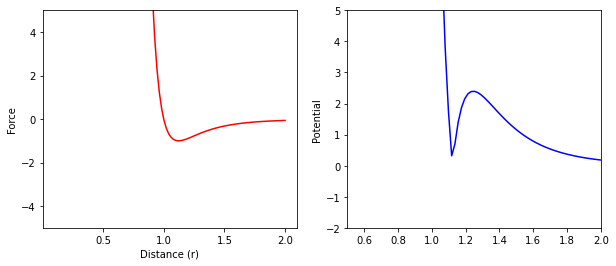

In [9]:
fig,ax = plt.subplots(1,2,figsize = (10,4))
forces=[]
potentials=[]
rs=[]
sigma = 1.0
rcut1 = sigma*2.5
l_da = 1.0
epsilon = 1.0
for r in np.linspace(0.1, 2, 100):
    force = soft_lj_force(r, epsilon, sigma, rcut1, l_da)
    rs.append(r)
    forces.append(force)
    potential = soft_lj_potential(r, epsilon, sigma, rcut1, l_da)
    potentials.append(potential)
    #print(f"r: {r:.2f}, Force: {force:.4f}")

ax[1].plot(rs, np.abs(forces), label='Soft LJ/cut Force', color='blue')
ax[0].plot(rs, potentials, label='Soft LJ/cut Potential', color='red')
ax[0].set_xlabel('Distance (r)')
ax[0].set_ylabel('Force')
ax[1].set_ylabel('Potential')
ax[0].set_ylim(-5,5)
ax[1].set_ylim(-2,5)
ax[1].set_xlim(0.5,2)

outputNoise_temp1.0_dt0.001_N17_seed1_damp50frame100.xyz
Unwrapped data shape: (18717, 8)
Unwrapped data head:
    timestep  id  type         x        y         z  x_unwrapped  y_unwrapped
0         0   1     1  -9.84883 -8.31231  0.000000     -9.84883     -8.31231
1       100   1     1  -9.96586 -8.22479  0.002628     -9.96586     -8.22479
2       200   1     1 -10.08350 -8.13762 -0.000705    -10.08350     -8.13762
3       300   1     1 -10.19030 -8.04627  0.001273    -10.19030     -8.04627
4       400   1     1 -10.29260 -7.95464  0.010007    -10.29260     -7.95464


In [32]:
# get number of particles
num_particles = data_unwrapped['id'].nunique()
print('num_particles',num_particles)
# get the number of timesteps
num_timesteps = data_unwrapped['timestep'].nunique()
print('num_timesteps',num_timesteps)
#get timestep values
timestep_values = data_unwrapped.iloc[1]['timestep'] - data_unwrapped.iloc[0]['timestep']
print('timestep_values',timestep_values)

TimeBins = np.linspace(0, np.max(data_unwrapped['timestep']), 25) #lets make 35 time bins (the first 5 are clustered)
TimeSteps = data_unwrapped['timestep'].unique()
#print('TimeBins',TimeBins)
##### make some empty arrays

RMSD_intime = np.zeros((len(TimeBins),len(TimeSteps)))
RMSD_SD_intime = np.zeros((len(TimeBins),len(TimeSteps)))
Counts_intime = np.zeros((len(TimeBins),len(TimeSteps)))
Counts_TimeInt = np.zeros((len(TimeBins)))

num_particles 3
num_timesteps 55001
timestep_values 10.0


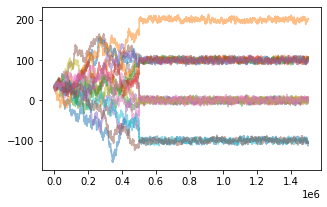

In [57]:
fig,ax = plt.subplots(figsize=(5, 3))
#fig2,ax2 = plt.subplots(1,3,figsize=(5, 3))
for cell_ in range(num_particles): #num_particles
    cell = cell_ + 1 # Adjust for 1-based indexing in the DataFrame
    trajectory = data_unwrapped[data_unwrapped['id'] == cell]
    ax.plot(trajectory['timestep'], trajectory['x_unwrapped'], label=f'Particle {cell}', alpha=0.5)
    dx = trajectory.groupby("id")["x_unwrapped"].diff()

TimeSteps_max 151


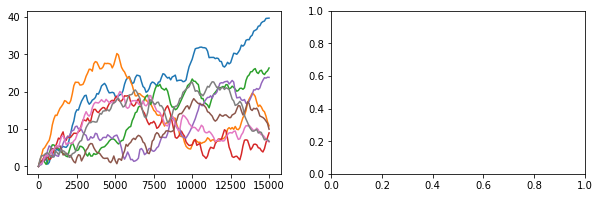

In [12]:
fig,ax = plt.subplots(1,2,figsize=(10, 3))
TimeSteps_max = data_unwrapped['timestep'].unique()
print("TimeSteps_max", len(TimeSteps_max))
RMSD_intime = np.zeros((len(TimeBins),len(TimeSteps_max)))
RMSD_SD_intime = np.zeros((len(TimeBins),len(TimeSteps_max)))
Counts_intime = np.zeros((len(TimeBins),len(TimeSteps_max)))
Counts_TimeInt = np.zeros((len(TimeBins)))

for ii in range(2): # 0 for RMSD, 1 for RMSD_SD
    for cell_ in range(num_particles): #num_particles
        RMSD_intime_Cell = np.zeros((len(TimeBins),len(TimeSteps_max)))
        cell = cell_ + 1 # Adjust for 1-based indexing in the DataFrame
        #print('cell',cell)
        trajectory = data_unwrapped[data_unwrapped['id'] == cell]
        #print("trajectory ID", trajectory['id'].unique(),'Cell',cell)
        Xs_ = trajectory['x_unwrapped']
        Ys_ = trajectory['y_unwrapped']
        Time = trajectory['timestep']
        
        startingIndex = 0 #np.argmin(np.abs(Time - 5000))
        for tb, startingT in enumerate(TimeBins[0:2]):
            index = np.argmin(np.abs(Time - startingT))
            if index > len(Time) - 1:
                continue
            
            Xs = Xs_[index:]  # Start from the specified index
            Ys = Ys_[index:]  # Start from the specified index
            TimeSteps = Time[index:]  # Start from the specified index

            DxTau = (Xs - Xs.iloc[0]) ** 2
            DyTau = (Ys - Ys.iloc[0]) ** 2
            
            RMSD = np.sqrt(DxTau + DyTau) #has length the same as the trajectory time - index
            Counts_TimeInt[ii]+=1


            #print("len(TimeSteps)", len(TimeSteps), "len(RMSD)", len(RMSD), "indexbin", index)
            for i, t in enumerate(TimeSteps):
                if i < len(RMSD):  # Include the length of this trajectory
                    if ii==0:

                        RMSD_intime[tb][i] += RMSD.iloc[i]
                        RMSD_intime_Cell[tb][i] += RMSD.iloc[i]
                        Counts_intime[tb][i] += 1
                    else:
                        #print("got here2")
                        RMSD_SD_intime[tb][i] += (RMSD.iloc[i] - RMSDAv[tb][i]) ** 2
        if ii==0:
            if cell%10 == 0:  # Plot every 10th cell
                ax[0].plot(TimeSteps_max,RMSD_intime_Cell[0][:], label='cell '+str(cell))
        
    if ii==0:
        RMSDAv = np.divide(RMSD_intime,Counts_intime) #RMSDs25 / np.maximum(counts25, 1)

RMSDs25_STD =np.sqrt(np.divide(RMSD_SD_intime , np.maximum(Counts_intime, 1)))  # Avoid division by zero
#ax[0].legend()

Plotting Simple over all time

output_damp1Sig2.5N86seed0_eps0.0cluster_size50.xyz


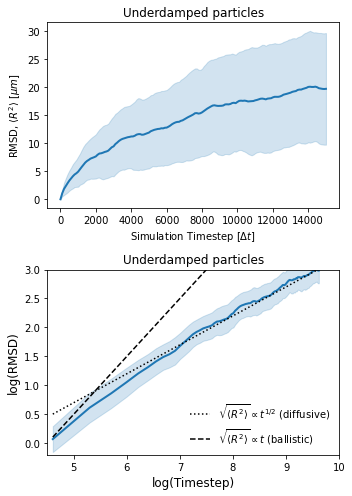

In [16]:
fig,ax = plt.subplots(2,1,figsize=(5, 7))
print(name)
logerr = np.divide(RMSDs25_STD[0][:len(TimeSteps_max)],np.multiply(RMSDAv[0][:len(TimeSteps_max)],np.log(10)))
log_lower = np.add(np.log(RMSDAv[0][:len(TimeSteps_max)]), -logerr)
log_upper = np.add(np.log(RMSDAv[0][:len(TimeSteps_max)]), logerr)
TransitionT0 = 100
TransitionT = 1000
TransitionT2 = 10000
clrs3[2] = 'tab:blue'
ax[0].plot(TimeSteps_max-TimeSteps_max[0], RMSDAv[0][:len(TimeSteps_max)], linewidth = 2,color=clrs3[2])
ax[0].fill_between(TimeSteps_max-TimeSteps_max[0], RMSDAv[0][:len(TimeSteps_max)] - RMSDs25_STD[0][:len(TimeSteps_max)], RMSDAv[0][:len(TimeSteps_max)] + RMSDs25_STD[0][:len(TimeSteps_max)], color=clrs3[2], alpha=0.2, label='RMSD STD')

#ax[0].plot([TransitionT,TransitionT],[0,25.0], linestyle='--', color=clrs3[2])
#ax[1].plot([np.log(TransitionT),np.log(TransitionT)],[0,np.log(250)], linestyle='-.', color=clrs3[2])
text = r"$\tau_{\mathrm{t}}$"
#ax[1].text(np.log(TransitionT)+0.1, np.log(250)-0.5, text, fontsize=15, color=clrs3[2])
# ax[0].plot([TransitionT2,TransitionT2],[0,250], linestyle='--', color='pink',label = "Transition")
# ax[1].plot([np.log(TransitionT2),np.log(TransitionT2)],[0,np.log(250)], linestyle='--', color='pink',label = "Transition")
# ax[0].plot([TransitionT0,TransitionT0],[0,250], linestyle='--', color='green',label = "Transition")
# ax[1].plot([np.log(TransitionT0),np.log(TransitionT0)],[0,np.log(250)], linestyle='--', color='green',label = "Transition")

ax[1].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(RMSDAv[0][:len(TimeSteps_max)]),linewidth = 2,color=clrs3[2])
ax[1].fill_between(np.log(TimeSteps_max-TimeSteps_max[0]), log_lower, log_upper, color=clrs3[2], alpha=0.2)

#ax[1].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(TimeSteps_max-TimeSteps_max[0])*0.5-0.3, linestyle = ':',label=r"$\sqrt{\langle R^2 \rangle} \propto t^{1/2}$ (diffusive)", color='black')
#ax[1].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(TimeSteps_max-TimeSteps_max[0])-4, linestyle = '--',label=r"$\sqrt{\langle R^2 \rangle} \propto t$ (ballistic)", color='black')
ax[1].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(TimeSteps_max-TimeSteps_max[0])*0.5-1.8, linestyle = ':',label=r"$\sqrt{\langle R^2 \rangle} \propto t^{1/2}$ (diffusive)", color='black')
ax[1].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(TimeSteps_max-TimeSteps_max[0])-4.5, linestyle = '--',label=r"$\sqrt{\langle R^2 \rangle} \propto t$ (ballistic)", color='black')

ax[0].set_xlabel(r'Simulation Timestep [$\Delta t$]')
ax[0].set_ylabel(r'RMSD, $\langle R^2 \rangle} \propto t$ [$\mu m$]')

#ax[0].set_title("RMSD for non-interacting particles")
ax[0].set_title("Underdamped particles",fontsize = 12)
ax[1].set_xlabel('log(Timestep)',fontsize = 12)
ax[1].set_ylabel('log(RMSD)',fontsize = 12)
ax[1].set_title("Underdamped particles",fontsize = 12)
#ax[1].set_title("Underdamped particles",fontsize = 12)
ax[1].set_xlim([4.5,10])
ax[1].set_ylim([-0.2,3])
ax[1].legend(frameon=False, loc='lower right')
#ax[1].legend(frameon=False)
fig.tight_layout()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


output_damp1Sig2.5N86seed0_eps0.0cluster_size50.xyz


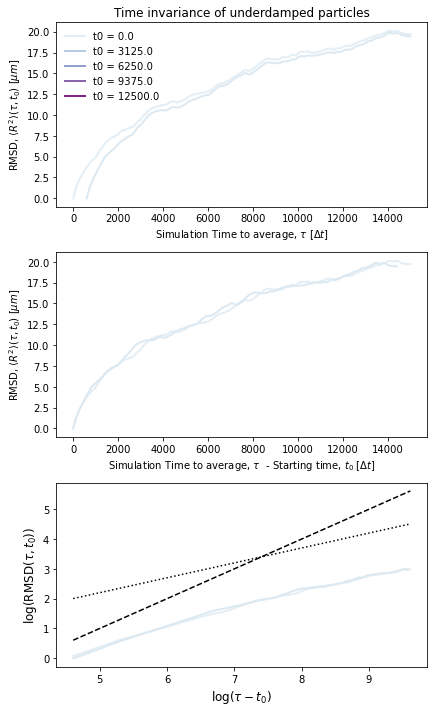

In [17]:
fig,ax = plt.subplots(3,1,figsize=(6, 10))
print(name)
for tb, startingT in enumerate(TimeBins[:-1]):
    index = np.argmin(np.abs(Time - startingT))

    logerr = np.divide(RMSDs25_STD[tb][:len(TimeSteps_max)],np.multiply(RMSDAv[tb][:len(TimeSteps_max)],np.log(10)))
    log_lower = np.add(np.log(RMSDAv[tb][:len(TimeSteps_max)]), -logerr)
    log_upper = np.add(np.log(RMSDAv[tb][:len(TimeSteps_max)]), logerr)
    if tb%5==0:
        ax[0].plot(TimeSteps_max[index:], RMSDAv[tb][:len(TimeSteps_max[index:])], linewidth = 2,color=cmap((tb+3)/(len(TimeBins)+3)),label = "t0 = "+str(TimeBins[tb]))
    else:  
        ax[0].plot(TimeSteps_max[index:], RMSDAv[tb][:len(TimeSteps_max[index:])], linewidth = 2,color=cmap((tb+3)/(len(TimeBins)+3)))
    ax[1].plot(TimeSteps_max[index:]-TimeSteps_max[index], RMSDAv[tb][:len(TimeSteps_max[index:])], linewidth = 2,color=cmap((tb+3)/(len(TimeBins)+3)))

    #ax[0].fill_between(TimeSteps_max[tb:]-TimeSteps_max[tb], RMSDAv[0][:len(TimeSteps_max)] - RMSDs25_STD[0][:len(TimeSteps_max)], RMSDAv[0][:len(TimeSteps_max)] + RMSDs25_STD[0][:len(TimeSteps_max)], color=clrs3[2], alpha=0.2, label='RMSD STD')


    ax[2].plot(np.log(TimeSteps_max[index:]-TimeSteps_max[index]), np.log(RMSDAv[tb][:len(TimeSteps_max[index:])]),linewidth = 2,color=cmap((tb+3)/(len(TimeBins)+3)))
    # ax[1].fill_between(np.log(TimeSteps_max-TimeSteps_max[0]), log_lower, log_upper, color=clrs3[2], alpha=0.2)

ax[2].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(TimeSteps_max-TimeSteps_max[0])*0.5-0.3, linestyle = ':',label=r"$\sqrt{\langle R^2 \rangle} \propto t^{1/2}$ (diffusive)", color='black')
ax[2].plot(np.log(TimeSteps_max-TimeSteps_max[0]), np.log(TimeSteps_max-TimeSteps_max[0])-4, linestyle = '--',label=r"$\sqrt{\langle R^2 \rangle} \propto t$ (ballistic)", color='black')

ax[0].set_xlabel(r'Simulation Time to average, $\tau$ [$\Delta t$]')
ax[0].set_ylabel(r'RMSD, $\langle R^2 \rangle (\tau,t_{0})$ [$\mu m$]')
ax[1].set_xlabel(r'Simulation Time to average, $\tau$  - Starting time, $t_{0}$ [$\Delta t$]')
ax[1].set_ylabel(r'RMSD, $\langle R^2 \rangle (\tau,t_{0})$ [$\mu m$]')

#ax[0].set_title("RMSD for non-interacting particles")
ax[0].set_title("Time invariance of underdamped particles",fontsize = 12)
ax[2].set_xlabel(r'log($\tau-t_{0}$)',fontsize = 12)
ax[2].set_ylabel(r'log(RMSD$(\tau,t_{0})$)',fontsize = 12)
#ax[1].set_title("Underdamped particles",fontsize = 12)
#ax[1].set_title("Underdamped particles",fontsize = 12)

ax[1].legend(frameon=False, loc='upper left')
ax[0].legend(frameon=False, loc='upper left')
#ax[1].legend(frameon=False)
fig.tight_layout()

What about Velocity distributions?

In [18]:
VelocitiesSq =[]
for cell_ in range(num_particles): #num_particles
    cell = cell_ + 1 # Adjust for 1-based indexing in the DataFrame
    trajectory = data_unwrapped[data_unwrapped['id'] == cell]
    Xs_ = trajectory['x_unwrapped']
    Ys_ = trajectory['y_unwrapped']
    Time = trajectory['timestep']
    dx2 = Xs_.diff().fillna(0)**2
    dy2 = Ys_.diff().fillna(0)**2
    dt = Time.diff().fillna(0)
    velocity_sq = (dx2 + dy2) / dt
    velocity_sq = velocity_sq.replace([np.inf, -np.inf], np.nan).dropna()
    VelocitiesSq.extend(velocity_sq.values.tolist())  # 👈 Use `extend` and convert to list of floats
    
VelocitiesSq = np.array(VelocitiesSq).reshape(1, -1)
print("shape of VelocitiesSq:", np.shape(VelocitiesSq))


shape of VelocitiesSq: (1, 12900)


In [19]:
counts, bin_edges = np.histogram(VelocitiesSq.flatten(), bins=50)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

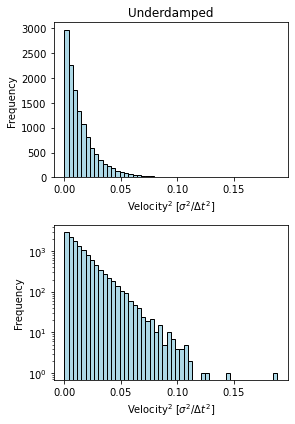

In [20]:
fig,ax = plt.subplots(2,1, figsize=(4.2,6))
ax[0].bar(bin_centers, counts, width=np.diff(bin_edges), align='center', edgecolor='k',facecolor='lightblue')
ax[0].set_xlabel(r'Velocity$^{2}$ $[\sigma^2/\Delta t^2]$')
ax[0].set_ylabel('Frequency')
ax[1].bar(bin_centers, counts, width=np.diff(bin_edges), align='center', edgecolor='k',facecolor='lightblue')
ax[1].set_xlabel(r'Velocity$^{2}$ $[\sigma^2/\Delta t^2]$')
ax[1].set_ylabel('Frequency')
ax[1].set_yscale('log')
ax[0].set_title('Underdamped', fontsize=12)
fig.tight_layout()

Compute velocity autocovariance

In [21]:
TimeBins = np.linspace(0, np.max(data_unwrapped['timestep']), 25) #lets make 35 time bins (the first 5 are clustered)
Velocity_auto = np.zeros((len(TimeBins)))
Counts = np.zeros((len(TimeBins)))
for cell_ in range(num_particles): #num_particles
    cell = cell_ + 1 # Adjust for 1-based indexing in the DataFrame
    #print('cell',cell)
    trajectory = data_unwrapped[data_unwrapped['id'] == cell]
    #print("trajectory ID", trajectory['id'].unique(),'Cell',cell)
    Xs = trajectory['x_unwrapped']
    Ys = trajectory['y_unwrapped']
    Time = trajectory['timestep']
    Ux = np.diff(Xs)
    Uy = np.diff(Ys)
    Velocities = np.stack((Ux, Uy), axis=1)
    max_lag = len(Velocities)
    # if np.any(np.abs(Velocities) > 4e3) or np.any(np.isnan(Velocities)):
    #     print("Velocities contain NaN or are larger than 4e2, skipping cell", cell)
    #     which_velocities = np.where(np.abs(Velocities) > 4e3)
    #     print("Velocities larger than 4e3:", Velocities[which_velocities])
    #     continue
    for i, tau in enumerate(TimeBins):
        if i < max_lag:
            dot_products = np.sum(
                Velocities[:max_lag - i] * Velocities[i:max_lag], axis=1
            )
            dot_products = dot_products[np.isfinite(dot_products)]
            dot_products = dot_products[np.abs(dot_products) < 1e7]  # new check here

            if len(dot_products) == 0:
                print("No valid dot products for cell", cell, "at time index", i)
                continue

            Velocity_auto[i] += np.sum(dot_products)
            Counts[i] += len(dot_products)
VAC = np.divide(Velocity_auto, Counts)



Text(0.5, 1.0, 'Underdamped')

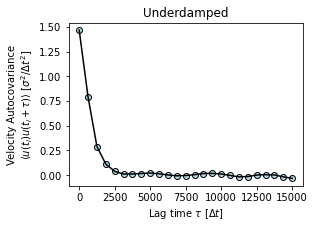

In [22]:


fig, ax = plt.subplots(1, figsize=(4.2, 3))
ax.plot(TimeBins, VAC,  linewidth=1.5,linestyle = '-', marker = '',label='Velocity Auto-Covariance',color = 'black')
ax.scatter(TimeBins, VAC, linewidth=1, marker = 'o',label='Velocity Auto-Covariance',  edgecolor='k',facecolor= 'lightblue')
ax.set_xlabel(r"Lag time $\tau$ $[\Delta t]$")
ax.set_ylabel("Velocity Autocovariance\n"+r"$\langle u(t_{i})u(t_{i}+\tau)\rangle$ [$\sigma^2/\Delta t^2$]")
#ax.set_xlim([0.5,5])
ax.set_title("Underdamped", fontsize=12)

Velocity power spectrum

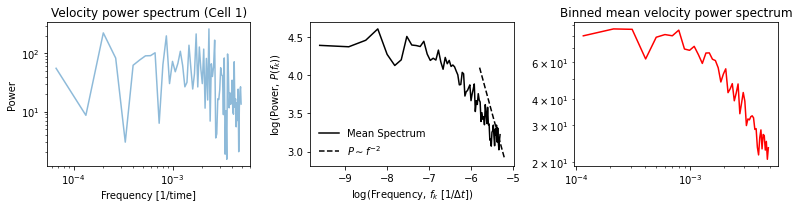

In [32]:
from scipy.fft import fft, fftfreq
power_spectra = []

fig,ax = plt.subplots(1,3, figsize=(11, 3))
ClusterSection =False
for cell_ in range(num_particles): #num_particles
    cell = cell_ + 1 # Adjust for 1-based indexing in the DataFrame
    #print('cell',cell)
    trajectory = data_unwrapped[data_unwrapped['id'] == cell]
    #print("trajectory ID", trajectory['id'].unique(),'Cell',cell)
    Xs = trajectory['x_unwrapped']
    Ys = trajectory['y_unwrapped']
    Time = trajectory['timestep']
    Ux = np.diff(Xs)
    Uy = np.diff(Ys)
    dt = np.mean(np.diff(Time))  # Average time step
    # Combine into speed or use components separately
    v = np.sqrt(Ux**2 + Uy**2)  # scalar speed per frame

    # Remove mean (detrend)
    #v = v - np.mean(v)

    # Compute FFT and power spectrum
    V_f = fft(v)
    power = np.abs(V_f)**2
    freqs = fftfreq(len(v), dt)

    # Keep only positive freqs
    idx = freqs > 0
    power_spectra.append(power[idx])

    if cell_ == 0:  # Plot one example
        
        #plt.loglog(freqs[idx], power[idx])
        ax[0].plot(freqs[idx], power[idx], label=f"Cell {cell}", alpha=0.5)
        ax[0].set_title(f"Velocity power spectrum (Cell {cell})")
        ax[0].set_xlabel("Frequency [1/time]")
        ax[0].set_ylabel("Power")
        #plt.grid(True)
        #plt.tight_layout()

# Optionally: compute mean spectrum across cells
power_spectra = np.array(power_spectra)
mean_spectrum = np.mean(power_spectra, axis=0)
ax[1].plot(np.log(freqs[idx]), np.log(mean_spectrum), color='black', label='Mean Spectrum')



#ax[1].set_title("Mean velocity power spectrum across cells")
ax[1].set_xlabel(r"log(Frequency, $f_{k}$ [1/$\Delta t$])")
ax[1].set_ylabel(r"log(Power, $P(f_{k}))$")
# make some that are averaged in bins along x-axis
num_bins = 50
bin_means = np.zeros(num_bins)
bin_edges = np.linspace(np.min(freqs[idx]), np.max(freqs[idx]), num_bins + 1)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
for i in range(num_bins):
    bin_mask = (freqs[idx] >= bin_edges[i]) & (freqs[idx] < bin_edges[i + 1])
    if np.any(bin_mask):
        bin_means[i] = np.mean(mean_spectrum[bin_mask])
#for i in range(3):
#    ax[i].set_ylim([10,1e4])
line = np.linspace(-5.8,-5.2,100)
line_min2 = np.add(np.multiply(line,-2),-7.5)

ax[1].plot(line,line_min2,linestyle='--', color='black', label=r'$P\sim f^{-2}$')
ax[2].set_title("Binned mean velocity power spectrum")
ax[1].legend(frameon=False)
ax[2].plot(bin_centers, bin_means, color='red', label='Binned Mean Spectrum')
ax[0].set_yscale('log')
#ax[1].set_yscale('log')
ax[0].set_xscale('log')
#ax[1].set_xscale('log')
ax[2].set_xscale('log')
ax[2].set_yscale('log')

fig.tight_layout()